In [1]:
!nvidia-smi

Fri Aug 21 23:42:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#%reload_ext autoreload
#%autoreload 2
%matplotlib inline

In [3]:
! pip install -Uqq fastai nbdev fastbook

In [4]:
from fastai.text.all import *

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
%cd /content/drive/MyDrive/udemy_project/Basics of NLP and Language Modeling

/content/drive/MyDrive/udemy_project/Basics of NLP and Language Modeling


#Data

In [7]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/udemy_project/Datasets/course_details.csv")
df.head(5)

,title,url,description,topic,topic_list
0,The Complete Python Bootcamp From Zero to Hero in Python,https://www.udemy.com/course/complete-python-bootcamp,"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most comprehensive, yet straight-forward, course for the Python programming language on Udemy! Whether you have never programmed before, already know basic syntax, or want to learn about the advanced features of Python, this course is for you! In this course we will teach you Python 3. With over 100 lectures and more than 21 hours of video this comprehensive course leaves no stone unturned! This course includes quizzes, tests, coding exercises and homework assignments as well as 3 major projec...",Python,"['Development', 'Programming Languages', 'Python']"
1,The Complete Full-Stack Web Development Bootcamp,https://www.udemy.com/course/the-complete-web-development-bootcamp,"Welcome to the Complete Web Development Bootcamp, the only course you need to learn to code and become a full-stack web developer. With 150,000+ ratings and a 4.8 average, my Web Development course is one of the HIGHEST RATED courses in the history of Udemy! At 62+ hours, this Web Development course is without a doubt the most comprehensive web development course available online. Even if you have zero programming experience, this course will take you from beginner to mastery. Here's why: The course is taught by the lead instructor at the App Brewery, London's leading in-person programmin...",Web Development,"['Development', 'Web Development', 'Node.Js', 'MongoDB', 'JavaScript']"
2,100 Days of Code™: The Complete Python Pro Bootcamp,https://www.udemy.com/course/100-days-of-code,"Welcome to the 100 Days of Code - The Complete Python Pro Bootcamp, the only course you need to learn to code with Python. With over 500,000 5 STAR reviews and a 4.8 average, my courses are some of the HIGHEST RATED courses in the history of Udemy! 100 days, 1 hour per day, learn to build 1 project per day, this is how you master Python. At 60+ hours, this Python course is without a doubt the most comprehensive Python course available anywhere online. Even if you have zero programming experience, this course will take you from beginner to professional. Here's why: The course is taught by...",Python,"['Development', 'Programming Languages', 'Python', 'Data Science', 'Flask', 'Web Scraping']"
3,The Web Developer Bootcamp 2026,https://www.udemy.com/course/the-web-developer-bootcamp,"Now with over 10 hours of React content. Massive new React ""expansion pack"" covers: React basics, JSX, props, state, Vite, MaterialUI, hooks, useEffect, React design patterns, and more. Hi! Welcome to the brand new version of The Web Developer Bootcamp, Udemy's most popular web development course. This course was completely overhauled to prepare students for the current job market, now with over 70 hours of total content! This is the only course you need to learn web development. There are a lot of options for online developer training, but this course is without a doubt the most comprehe...",Web Development,"['Development', 'Web Development']"
4,"React - The Complete Guide (incl. Next.js, Redux)",https://www.udemy.com/course/react-the-complete-guide-incl-redux,"This bestselling course by the author of ""React Key Concepts"" has turned more students into ReactJS developers than any other courses - more than 1,000,000 and counting! - Fully updated for React 19! - A Course For Busy Customers & Business Professionals! This course also comes with two paths which you can take: The ""complete"" path (full >40h course) and the ""summary"" (fast-track) path (~4h summary module) - you can choose the path that best fits your time requirements! React.js is THE most popular JavaScript library you can use and learn these days to build modern, reactive user interfa...",React JS,"['Development', 'Programming Languages', 'React JS', 'React Hooks']"


In [8]:
df.shape

(11061, 5)

In [9]:
topics_list = df.topic_list.to_list()
topic_count = {}
for topics in topics_list:
  topic_list = eval(topics)
  for topic in topic_list:
    if topic in topic_count.keys():
      topic_count[topic] += 1
    else:
      topic_count[topic] = 1
print(f"Number of Topics: {len(topic_count)}")
print(topic_count)

Number of Topics: 2436
{'Development': 1598, 'Programming Languages': 336, 'Python': 272, 'Web Development': 479, 'Node.Js': 38, 'MongoDB': 15, 'JavaScript': 103, 'Data Science': 243, 'Flask': 9, 'Web Scraping': 10, 'React JS': 61, 'React Hooks': 6, 'Angular': 34, 'Java': 125, 'Machine Learning': 88, 'R (programming language)': 17, 'Software Development Tools': 101, 'Prompt Engineering': 38, 'Software Testing': 160, 'Selenium WebDriver': 28, 'Automation': 50, 'CSS': 68, 'Web Design': 142, 'Responsive Design': 14, 'HTML': 54, 'OpenAI API': 9, 'ChatGPT': 198, 'Database Design & Development': 98, 'SQL': 105, 'MySQL': 33, 'Game Development': 60, 'Game Development Fundamentals': 44, '2D Game Development': 13, 'Unity': 47, 'C# (programming language)': 57, 'Mobile Development': 58, 'Swift': 10, 'Xcode': 4, 'ARKit': 2, 'iOS Development': 17, 'Spring Framework': 30, 'Spring MVC': 9, 'Hibernate': 7, 'Dart (programming language)': 8, 'Google Flutter': 9, 'Front End Web Development': 26, 'Redux Fr

In [10]:
df.isna().sum()

,0
title,0
url,0
description,4
topic,4
topic_list,0


In [11]:
df = df.dropna().reset_index(drop=True)

In [12]:
df.shape

(11057, 5)

In [13]:
type(eval(df['topic_list'][0]))

list

In [14]:
topic_list = []
indices_to_drop = []
for idx, topics in enumerate(df.topic_list.to_list()):
  topics_list = eval(topics)
  if len(topics_list):
    topic_list.append(topics_list[0])
  else:
    indices_to_drop.append(idx)

df = df.drop(indices_to_drop).reset_index(drop=True)
df.shape

(11057, 5)

In [15]:
df['primary_topic'] = topic_list

In [16]:
df.head()

,title,url,description,topic,topic_list,primary_topic
0,The Complete Python Bootcamp From Zero to Hero in Python,https://www.udemy.com/course/complete-python-bootcamp,"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most comprehensive, yet straight-forward, course for the Python programming language on Udemy! Whether you have never programmed before, already know basic syntax, or want to learn about the advanced features of Python, this course is for you! In this course we will teach you Python 3. With over 100 lectures and more than 21 hours of video this comprehensive course leaves no stone unturned! This course includes quizzes, tests, coding exercises and homework assignments as well as 3 major projec...",Python,"['Development', 'Programming Languages', 'Python']",Development
1,The Complete Full-Stack Web Development Bootcamp,https://www.udemy.com/course/the-complete-web-development-bootcamp,"Welcome to the Complete Web Development Bootcamp, the only course you need to learn to code and become a full-stack web developer. With 150,000+ ratings and a 4.8 average, my Web Development course is one of the HIGHEST RATED courses in the history of Udemy! At 62+ hours, this Web Development course is without a doubt the most comprehensive web development course available online. Even if you have zero programming experience, this course will take you from beginner to mastery. Here's why: The course is taught by the lead instructor at the App Brewery, London's leading in-person programmin...",Web Development,"['Development', 'Web Development', 'Node.Js', 'MongoDB', 'JavaScript']",Development
2,100 Days of Code™: The Complete Python Pro Bootcamp,https://www.udemy.com/course/100-days-of-code,"Welcome to the 100 Days of Code - The Complete Python Pro Bootcamp, the only course you need to learn to code with Python. With over 500,000 5 STAR reviews and a 4.8 average, my courses are some of the HIGHEST RATED courses in the history of Udemy! 100 days, 1 hour per day, learn to build 1 project per day, this is how you master Python. At 60+ hours, this Python course is without a doubt the most comprehensive Python course available anywhere online. Even if you have zero programming experience, this course will take you from beginner to professional. Here's why: The course is taught by...",Python,"['Development', 'Programming Languages', 'Python', 'Data Science', 'Flask', 'Web Scraping']",Development
3,The Web Developer Bootcamp 2026,https://www.udemy.com/course/the-web-developer-bootcamp,"Now with over 10 hours of React content. Massive new React ""expansion pack"" covers: React basics, JSX, props, state, Vite, MaterialUI, hooks, useEffect, React design patterns, and more. Hi! Welcome to the brand new version of The Web Developer Bootcamp, Udemy's most popular web development course. This course was completely overhauled to prepare students for the current job market, now with over 70 hours of total content! This is the only course you need to learn web development. There are a lot of options for online developer training, but this course is without a doubt the most comprehe...",Web Development,"['Development', 'Web Development']",Development
4,"React - The Complete Guide (incl. Next.js, Redux)",https://www.udemy.com/course/react-the-complete-guide-incl-redux,"This bestselling course by the author of ""React Key Concepts"" has turned more students into ReactJS developers than any other courses - more than 1,000,000 and counting! - Fully updated for React 19! - A Course For Busy Customers & Business Professionals! This course also comes with two paths which you can take: The ""complete"" path (full >40h course) and the ""summary"" (fast-track) path (~4h summary module) - you can choose the path that best fits your time requirements! React.js is THE most popular JavaScript library you can use and learn these days to build modern, reactive user interfa...",React JS,"['Development', 'Programming Lang

We will first perform single-label course classification using the main category of each Udemy course. Later, we will implement multi-label classification using subcategories and sub-subcategories.

In [17]:
df['primary_topic'].value_counts()

,count
primary_topic,
Development,1597
Finance & Accounting,1586
Marketing,1583
Business,1583
Personal Development,1577
IT & Software,1561
Design,1554
Udemy Free Resource Center,13
Vodafone,2


### Removing rare topics

In [18]:
topic_count = df['primary_topic'].value_counts()
threshold = int(len(df) * 0.005)
rare_topics = [cat for cat, count in topic_count.items() if count < threshold]
len(rare_topics), rare_topics[:5]

(3, ['Udemy Free Resource Center', 'Vodafone', 'Health & Fitness'])

In [19]:
rare_indices_to_drop = [idx for idx, row in df.iterrows() if row['primary_topic'] in rare_topics]
len(rare_indices_to_drop)

16

In [20]:
df = df.drop(rare_indices_to_drop).reset_index(drop=True)
df.shape

(11041, 6)

In [21]:
df['primary_topic'].value_counts()

,count
primary_topic,
Development,1597
Finance & Accounting,1586
Business,1583
Marketing,1583
Personal Development,1577
IT & Software,1561
Design,1554


In [22]:
len(df['primary_topic'].value_counts())

7

In [23]:
df.describe(include='object')

,title,url,description,topic,topic_list,primary_topic
count,11041,11041,11041,11041,11041,11041
unique,11021,11041,11033,1959,8303,7
top,HTML & CSS - Certification Course for Beginners,https://www.udemy.com/course/professional-ethics-for-helping-professions,"We live in an instant gratification culture today. So everyone (especially everyone on Instagram) expects things overnight. But the reality is growth won't come from a ""lucky"" post that goes viral...no matter how many people tell you that you just need to hit the explore page & then you too can be ""Instagram famous."" People like that want you to believe they have the ""secret"" to growth so they can sell you on their expertise & products. But anyone who's ACTUALLY grown on Instagram (or anywhere for that matter) understands that it doesn't happen overnight or by some stroke of luck. You w...",Python,"['Development', 'Programming Languages', 'Python']",Development
freq,2,1,3,133,47,1597


# Data Processing


## Tokenization

In [24]:
desc = df.description[0]
desc[:110]

"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most compreh"

In [25]:
desc[:110].split() # White Space Tokenization

['Become',
 'a',
 'Python',
 'Programmer',
 'and',
 'learn',
 'one',
 'of',
 "employer's",
 'most',
 'requested',
 'skills',
 'of',
 '2023!',
 'This',
 'is',
 'the',
 'most',
 'compreh']

In [26]:
doc(SpacyTokenizer)

In [27]:
spacy = SpacyTokenizer()
tokens = first(spacy([desc[:110]]))
tokens

['Become', 'a', 'Python', 'Programmer', 'and', 'learn', 'one', 'of', 'employer', "'s", 'most', 'requested', 'skills', 'of', '2023', '!', 'This', 'is', 'the', 'most', 'compreh']

In [28]:
print(coll_repr(tokens, 20))

(#21) ['Become', 'a', 'Python', 'Programmer', 'and', 'learn', 'one', 'of', 'employer', "'s", 'most', 'requested', 'skills', 'of', '2023', '!', 'This', 'is', 'the', 'most'...]


In [29]:
# Fastai's tokenizer
tokenizer = Tokenizer(spacy)
print(coll_repr(tokenizer(desc[:110]), 25))

(#26) ['xxbos', 'xxmaj', 'become', 'a', 'xxmaj', 'python', 'xxmaj', 'programmer', 'and', 'learn', 'one', 'of', 'employer', "'s", 'most', 'requested', 'skills', 'of', '2023', '!', 'xxmaj', 'this', 'is', 'the', 'most'...]


`xxbos` => Indicates the beginning of a text <br/>
`xxmaj` => Indicates the next word begins with a capital <br/>
`xxunk` => Indicates the word is unknown

In [30]:
# Adds these process to tokenization by default
defaults.text_proc_rules

[<function fastai.text.core.fix_html(x)>,
 <function fastai.text.core.replace_rep(t)>,
 <function fastai.text.core.replace_wrep(t)>,
 <function fastai.text.core.spec_add_spaces(t)>,
 <function fastai.text.core.rm_useless_spaces(t)>,
 <function fastai.text.core.replace_all_caps(t)>,
 <function fastai.text.core.replace_maj(t)>,
 <function fastai.text.core.lowercase(t, add_bos=True, add_eos=False)>]

`fix_html` => Replaces special HTML characters with a readable version <br/>
`replace_rep` => Replaces any character repeated three times or more with a special token for repetition (xxrep), the number of times it's repeated, then the character <br/>
`replace_wrep` => Replaces any word repeated three times or more with a special token for word repetition (xxwrep), the number of times it's repeated, then the word <br/>
`spec_add_spaces` => Adds spaces around / and # <br/>
`rm_useless_spaces` => Removes all repetitions of the space character <br/>
`replace_all_caps` => Lowercases a word written in all caps and adds a special token for all caps (xxup) in front of it <br/>
`replace_maj` => Lowercases a capitalized word and adds a special token for capitalized (xxmaj) in front of it <br/>
`lowercase` => Lowercases all text and adds a special token at the beginning (xxbos) and/or the end (xxeos) <br/>

In [31]:
text = "rrrrrrrrrrrrrrrrrrrr MasterCourse MasterCourse MasterCourse data/ml                NLP"
tokenizer = Tokenizer(spacy)
print(coll_repr(tokenizer(text), 25))

['xxbos', 'xxrep', '20', 'r', 'xxwrep', '3', 'mastercourse', 'data', '/', 'ml', 'xxup', 'nlp']


## Subword Tokenization


In [32]:
doc(SentencePieceTokenizer)

In [33]:
corpus = df.description[:1000]

In [34]:
def subword(vocab_size):
  sp_tokenizer = SentencePieceTokenizer(vocab_sz=vocab_size)
  sp_tokenizer.setup(corpus) # Created corpus to create subword vocabulary
  return " ".join(first(sp_tokenizer([desc]))[:50])

In [35]:
subword(500)

"▁B e com e ▁a ▁Python ▁Pro g ra m m er ▁and ▁learn ▁on e ▁of ▁ e mp lo y er ' s ▁most ▁re q u est ed ▁s k i ll s ▁of ▁20 2 3 ! ▁This ▁is ▁the ▁most ▁comprehensive , ▁ y et"

In [36]:
subword(1000)

"▁B e com e ▁a ▁Python ▁Pro gra m m er ▁and ▁learn ▁one ▁of ▁e mp lo y er ' s ▁most ▁request ed ▁skills ▁of ▁20 2 3 ! ▁This ▁is ▁the ▁most ▁comprehensive , ▁ y et ▁st ra ight - for ward , ▁course ▁for ▁the"

In [37]:
subword(10000)

"▁Become ▁a ▁Python ▁Programmer ▁and ▁learn ▁one ▁of ▁employer ' s ▁most ▁requested ▁skills ▁of ▁2023 ! ▁This ▁is ▁the ▁most ▁comprehensive , ▁yet ▁straight - forward , ▁course ▁for ▁the ▁Python ▁programming ▁language ▁on ▁Udemy ! ▁Whether ▁you ▁have ▁never ▁programmed ▁before , ▁already ▁know ▁basic ▁syntax , ▁or"

## Numericalization


In [38]:
tokenizer = Tokenizer(spacy)
print(coll_repr(tokenizer(desc[:110]), 25))

(#26) ['xxbos', 'xxmaj', 'become', 'a', 'xxmaj', 'python', 'xxmaj', 'programmer', 'and', 'learn', 'one', 'of', 'employer', "'s", 'most', 'requested', 'skills', 'of', '2023', '!', 'xxmaj', 'this', 'is', 'the', 'most'...]


In [39]:
tokens = corpus[:100].map(tokenizer)
tokens[0]

(#453) ['xxbos', 'xxmaj', 'become', 'a', 'xxmaj', 'python', 'xxmaj', 'programmer', 'and', 'learn', 'one', 'of', 'employer', "'s", 'most', 'requested', 'skills', 'of', '2023', '!', 'xxmaj', 'this', 'is', 'the', 'most', 'comprehensive', ',', 'yet', 'straight', '-', 'forward', ',', 'course', 'for', 'the', 'xxmaj', 'python', 'programming', 'language', 'on', 'xxmaj', 'udemy', '!', 'xxmaj', 'whether', 'you', 'have', 'never', 'programmed', 'before', ',', 'already', 'know', 'basic', 'syntax', ',', 'or', 'want', 'to', 'learn', 'about', 'the', 'advanced', 'features', 'of', 'xxmaj', 'python', ',', 'this', 'course', 'is', 'for', 'you', '!', 'xxmaj', 'in', 'this', 'course', 'we', 'will', 'teach', 'you', 'xxmaj', 'python', '3', '.', 'xxmaj', 'with', 'over', '100', 'lectures', 'and', 'more', 'than', '21', 'hours', 'of', 'video', 'this', 'comprehensive', 'course', 'leaves', 'no', 'stone', 'unturned', '!', 'xxmaj', 'this', 'course', 'includes', 'quizzes', ',', 'tests', ',', 'coding', 'exercises', 'and'

In [40]:
doc(Numericalize)

In [41]:
num = Numericalize()
num.setup(tokens)
coll_repr(num.vocab,20)

"(#2376) ['xxunk', 'xxpad', 'xxbos', 'xxeos', 'xxfld', 'xxrep', 'xxwrep', 'xxup', 'xxmaj', ',', '.', 'and', 'the', 'to', 'you', '-', 'a', 'course', 'of', 'in'...]"

In [42]:
corpus[0]

"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most comprehensive, yet straight-forward, course for the Python programming language on Udemy! Whether you have never programmed before, already know basic syntax, or want to learn about the advanced features of Python, this course is for you! In this course we will teach you Python 3. With over 100 lectures and more than 21 hours of video this comprehensive course leaves no stone unturned! This course includes quizzes, tests, coding exercises and homework assignments as well as 3 major projects to create a Python project portfolio! Learn how to use Python for real-world tasks, such as working with PDF Files, sending emails, reading Excel files, Scraping websites for informations, working with image files, and much more! This course will teach you Python in a practical manner, with every lecture comes a full coding screencast and a corresponding code notebook! Learn in whatever manner is 

In [43]:
# Encoding
nums = num(tokens[0])
nums

TensorText([   2,    8,  201,   16,    8,   45,    8,  572,   11,   32,   82,
              18,  878,   53,   75,    0,   87,   18,  684,   24,    8,   20,
              21,   12,   75,  220,    9,  727, 1466,   15,  879,    9,   17,
              23,   12,    8,   45,   50,  125,   28,    8,  102,   24,    8,
             425,   14,   46,  304, 1467,  296,    9,  340,  142,  273,  685,
               9,   52,  114,   13,   32,  101,   12,  118,  175,   18,    8,
              45,    9,   20,   17,   21,   23,   14,   24,    8,   19,   20,
              17,   39,   29,  186,   14,    8,   45,   70,   10,    8,   22,
             112,  410,  279,   11,   49,  207,  933,  223,   18,  202,   20,
             220,   17,    0,   85,    0,    0,   24,    8,   20,   17,  411,
             823,    9,  824,    9,  130,  195,   11, 1657,  825,   35,  108,
              35,   70,  880,   80,   13,  124,   16,    8,   45,  109,  728,
              24,    8,   32,   34,   13,   68,    8,   45,   23

In [44]:
# Decoding
' '.join(num.vocab[o] for o in nums)

"xxbos xxmaj become a xxmaj python xxmaj programmer and learn one of employer 's most xxunk skills of 2023 ! xxmaj this is the most comprehensive , yet straight - forward , course for the xxmaj python programming language on xxmaj udemy ! xxmaj whether you have never programmed before , already know basic syntax , or want to learn about the advanced features of xxmaj python , this course is for you ! xxmaj in this course we will teach you xxmaj python 3 . xxmaj with over 100 lectures and more than 21 hours of video this comprehensive course xxunk no xxunk xxunk ! xxmaj this course includes quizzes , tests , coding exercises and homework assignments as well as 3 major projects to create a xxmaj python project portfolio ! xxmaj learn how to use xxmaj python for real - world tasks , such as working with xxup pdf xxmaj files , sending emails , reading xxmaj excel files , xxmaj scraping websites for xxunk , working with image files , and much more ! xxmaj this course will teach you xxmaj py

## Prepping data for LMs

In [45]:
# bs: batch size
# seq_len: maximum sequence length
dls_lm = TextDataLoaders.from_df(df,
                                 text_col='description',
                                 is_lm=True,
                                 bs=16,
                                 seq_len=512,
                                 splitter = RandomSplitter(valid_pct=0.1, seed=42))

In [46]:
dls_lm.show_batch(max_n=3)

xxbos xxmaj ever wondered how xxup ai technologies like openai chatgpt , xxup gpt-4 , xxup dall - e , xxmaj midjourney , and xxmaj stable xxmaj diffusion really work ? xxmaj in this course , you will learn the foundations of these groundbreaking applications . xxmaj welcome ! xxmaj this is xxmaj deep xxmaj learning , xxmaj machine xxmaj learning , and xxmaj data xxmaj science xxmaj prerequisites : xxmaj the xxmaj numpy xxmaj stack in xxmaj python . xxmaj one question or concern i get a lot is that people want to learn deep learning and data science , so they take these courses , but they get left behind because they do n’t know enough about the xxmaj numpy stack in order to turn those concepts into code . xxmaj even if i write the code in full , if you do n’t know xxmaj numpy ,
write independent unit tests for restful web services talking with multiple layers - web , business and data . xxmaj you will learn how to write integration tests using an in memory database xxup h2 . xxmaj you 

In [47]:
# dls_lm = torch.load("dataloaders/lm_dls.pkl")

#Modeling

In [48]:
doc(AWD_LSTM)

In [49]:
doc(language_model_learner)

In [50]:
doc(Perplexity)

`drop_mult` => what dropout to apply at the head layers

In [51]:
learner = language_model_learner(
    dls_lm, AWD_LSTM, drop_mult=0.3,
    metrics=[accuracy, Perplexity()]).to_fp16()

In [52]:
learner.model

SequentialRNN(
  (0): AWD_LSTM(
    (encoder): Embedding(23784, 400, padding_idx=1)
    (encoder_dp): EmbeddingDropout(
      (emb): Embedding(23784, 400, padding_idx=1)
    )
    (rnns): ModuleList(
      (0): WeightDropout(
        (module): LSTM(400, 1152, batch_first=True)
      )
      (1): WeightDropout(
        (module): LSTM(1152, 1152, batch_first=True)
      )
      (2): WeightDropout(
        (module): LSTM(1152, 400, batch_first=True)
      )
    )
    (input_dp): RNNDropout()
    (hidden_dps): ModuleList(
      (0-2): 3 x RNNDropout()
    )
  )
  (1): LinearDecoder(
    (decoder): Linear(in_features=400, out_features=23784, bias=True)
    (output_dp): RNNDropout()
  )
)

# Stage-0

In [53]:
learner.freeze()

<div></div>

SuggestedLRs(slide=0.010964781977236271, valley=0.002511886414140463)

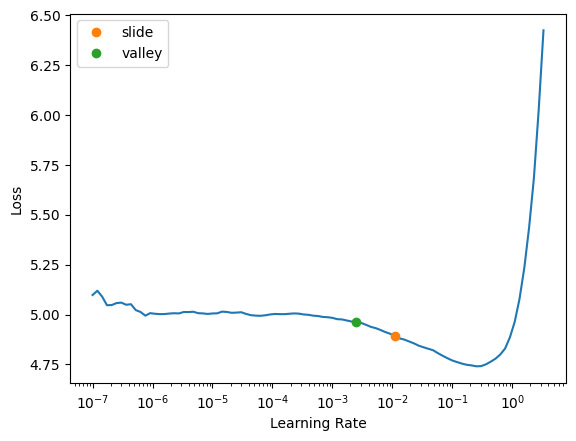

In [54]:
learner.lr_find(suggest_funcs=(slide, valley))

In [56]:
learner.fit_one_cycle(3, 2.5e-3)

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,3.338498,3.416671,0.363139,30.467819,03:35
1,3.308183,3.389994,0.366098,29.665771,03:34
2,3.251519,3.383945,0.367148,29.486853,03:32


In [57]:
learner.save(f"lm-stage-0")

Path('models/lm-stage-0.pth')

#Stage-1

In [ ]:
# learner.load(f"lm-stage-0")

In [58]:
learner.unfreeze()

<div></div>

SuggestedLRs(slide=0.00015848931798245758, valley=0.0002290867705596611)

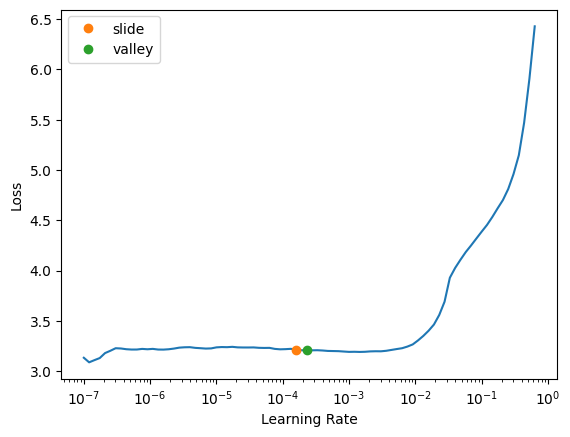

In [59]:
learner.lr_find(suggest_funcs=(slide, valley))

In [60]:
learner.fit_one_cycle(5, slice(1e-5, 2.3e-4))

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,3.230767,3.355335,0.371334,28.655216,03:49


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,3.230767,3.355335,0.371334,28.655216,03:49
1,3.167185,3.318613,0.376653,27.622021,03:48
2,3.174348,3.297789,0.379475,27.052761,03:47
3,3.122786,3.289041,0.380694,26.817135,03:54
4,3.120990,3.287698,0.380956,26.781137,03:49


In [61]:
learner.save(f"lm-stage-1")

Path('models/lm-stage-1.pth')

In [62]:
learner.model

SequentialRNN(
  (0): AWD_LSTM(
    (encoder): Embedding(23784, 400, padding_idx=1)
    (encoder_dp): EmbeddingDropout(
      (emb): Embedding(23784, 400, padding_idx=1)
    )
    (rnns): ModuleList(
      (0): WeightDropout(
        (module): LSTM(400, 1152, batch_first=True)
      )
      (1): WeightDropout(
        (module): LSTM(1152, 1152, batch_first=True)
      )
      (2): WeightDropout(
        (module): LSTM(1152, 400, batch_first=True)
      )
    )
    (input_dp): RNNDropout()
    (hidden_dps): ModuleList(
      (0-2): 3 x RNNDropout()
    )
  )
  (1): LinearDecoder(
    (decoder): Linear(in_features=400, out_features=23784, bias=True)
    (output_dp): RNNDropout()
  )
)

In [63]:
# Only saving the encoder, because we do not need decoder anymore for classification
learner.save_encoder("lm-encoder-finetuned")